# Задание 1. Базовая обработка изображений

1. Загрузите изображение в оттенках серого `sar_1_gray.jpg`.
2. Постройте гистограмму.
3. Реализуйте алгоритм гамма-коррекции с параметром гамма < 1 и > 1.
4. Сравните исходное изображение и скорректированное при помощи гамма-фильтра (MSE, SSIM).
5. Реализуйте алгоритм статистической цветокоррекции на основе статистики `eq_gray`.
6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

Для каждого решения — напечатайте результат.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

Matplotlib is building the font cache; this may take a moment.


## 1. Загрузка изображения в оттенках серого

[1] Изображение загружено: shape=(900, 1600), dtype=uint8, min=0, max=255, mean=107.72, std=60.80


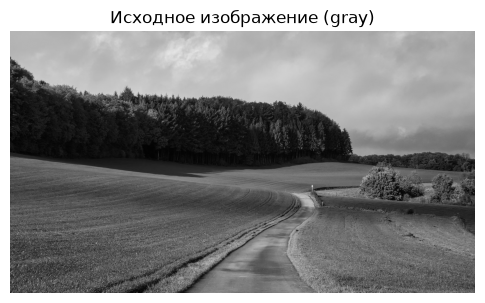

In [2]:
img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Не найден sar_1_gray.jpg")

print(f"[1] Изображение загружено: shape={img.shape}, dtype={img.dtype}, "
      f"min={img.min()}, max={img.max()}, mean={img.mean():.2f}, std={img.std():.2f}")

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение (gray)')
plt.axis('off')
plt.show()

## 2. Построение гистограммы

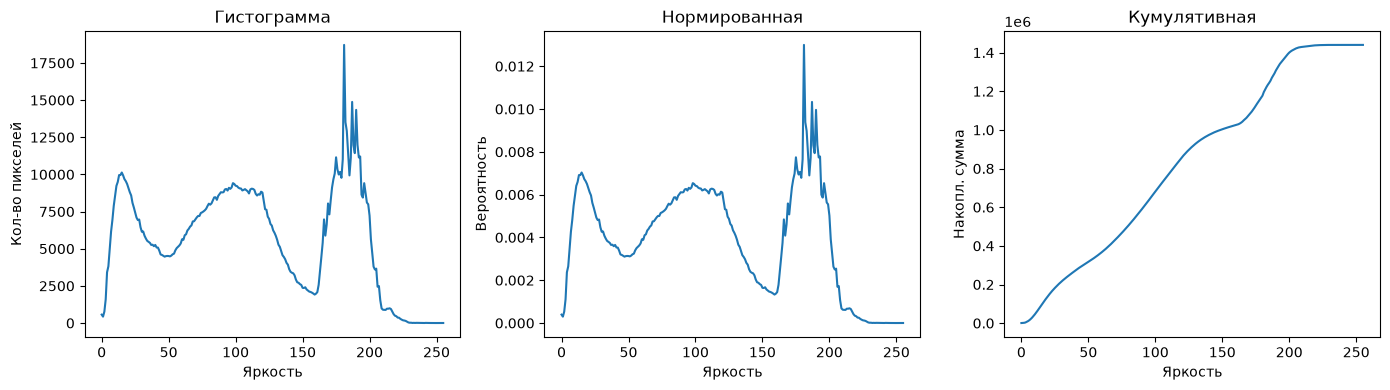

[2] Гистограмма построена. Пик гистограммы на яркости: 181
[2] Сумма всех бинов гистограммы = 1440000.0 (пикселей: 1440000)


In [3]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
hist_norm = hist / hist.sum()
hist_cum = hist.cumsum()

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1); plt.plot(hist);      plt.title('Гистограмма');      plt.xlabel('Яркость'); plt.ylabel('Кол-во пикселей')
plt.subplot(1, 3, 2); plt.plot(hist_norm); plt.title('Нормированная');   plt.xlabel('Яркость'); plt.ylabel('Вероятность')
plt.subplot(1, 3, 3); plt.plot(hist_cum);  plt.title('Кумулятивная');    plt.xlabel('Яркость'); plt.ylabel('Накопл. сумма')
plt.tight_layout()
plt.show()

print(f"[2] Гистограмма построена. Пик гистограммы на яркости: {np.argmax(hist)}")
print(f"[2] Сумма всех бинов гистограммы = {hist.sum()} (пикселей: {img.size})")

## 3. Гамма-коррекция (gamma < 1 и gamma > 1)

[3] Гамма-коррекция выполнена:
    gamma=2.0 (осветление): mean=156.43, std=53.22
    gamma=0.5 (затемнение):  mean=59.56, std=52.92


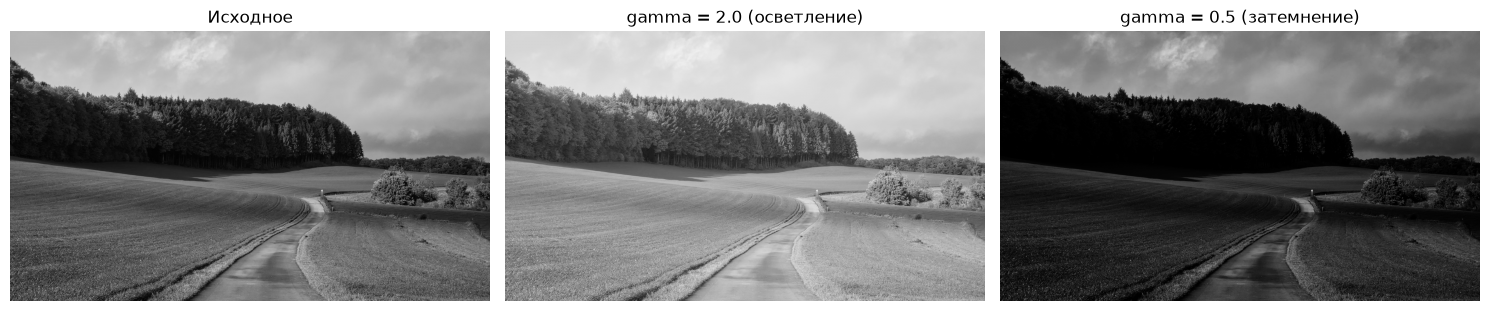

In [4]:
def gamma_correct(image, gamma):
    """Гамма-коррекция через LUT.
    gamma > 1 — осветление (inv_gamma < 1),
    gamma < 1 — затемнение (inv_gamma > 1).
    """
    inv_gamma = 1.0 / gamma
    table = ((np.arange(256) / 255.0) ** inv_gamma * 255).astype(np.uint8)
    return cv2.LUT(image, table)

gamma_gt1 = gamma_correct(img, 2.0)   # осветление
gamma_lt1 = gamma_correct(img, 0.5)   # затемнение

print("[3] Гамма-коррекция выполнена:")
print(f"    gamma=2.0 (осветление): mean={gamma_gt1.mean():.2f}, std={gamma_gt1.std():.2f}")
print(f"    gamma=0.5 (затемнение):  mean={gamma_lt1.mean():.2f}, std={gamma_lt1.std():.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, title in zip(ax, [img, gamma_gt1, gamma_lt1],
                        ['Исходное',
                         'gamma = 2.0 (осветление)',
                         'gamma = 0.5 (затемнение)']):
    a.imshow(im, cmap='gray'); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()

## 4. Сравнение: MSE и SSIM (исходное vs гамма-скорректированные)

In [5]:
def compare(a, b, name):
    m = mse(a, b)
    s = ssim(a, b, data_range=255)
    print(f"[4] {name}: MSE={m:.3f}, SSIM={s:.4f}")
    return m, s

compare(img, gamma_gt1, "исходное vs gamma>1 (2.0, осветление)")
compare(img, gamma_lt1, "исходное vs gamma<1 (0.5, затемнение)")

[4] исходное vs gamma>1 (2.0, осветление): MSE=2538.052, SSIM=0.8310
[4] исходное vs gamma<1 (0.5, затемнение): MSE=2576.041, SSIM=0.6302


(np.float64(2576.040772916667), np.float64(0.630236681117725))

## 5. Линейное растяжение гистограммы (linear contrast stretching)

[5] Линейное растяжение гистограммы:
    исходное:  min=0, max=255, mean=107.72, std=60.80
    результат: min=0, max=255, mean=107.72, std=60.80


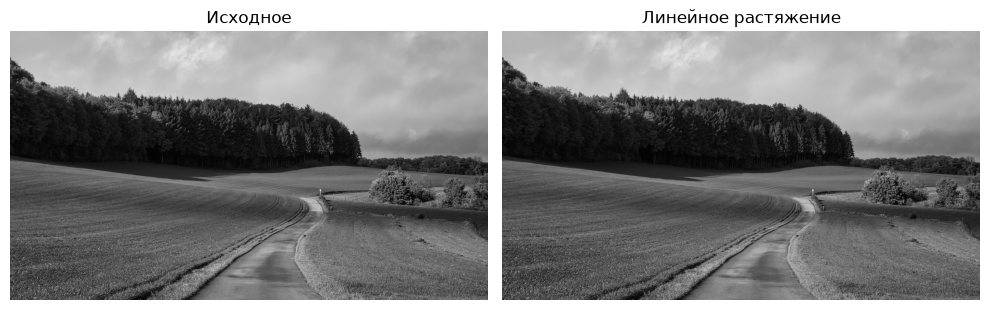

In [6]:
## 5. Линейное растяжение гистограммы (linear contrast stretching)
src_min = float(img.min())
src_max = float(img.max())

def linear_stretch(src, out_min=0, out_max=255):
    """Линейное растяжение диапазона [src_min, src_max] -> [out_min, out_max]."""
    s_f = src.astype(np.float32)
    lo, hi = float(s_f.min()), float(s_f.max())
    out = (s_f - lo) * (out_max - out_min) / (hi - lo + 1e-6) + out_min
    return np.clip(out, 0, 255).astype(np.uint8)

lin_img = linear_stretch(img, 0, 255)

print("[5] Линейное растяжение гистограммы:")
print(f"    исходное:  min={src_min:.0f}, max={src_max:.0f}, "
      f"mean={img.mean():.2f}, std={img.std():.2f}")
print(f"    результат: min={lin_img.min()}, max={lin_img.max()}, "
      f"mean={lin_img.mean():.2f}, std={lin_img.std():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, im, title in zip(ax, [img, lin_img],
                        ['Исходное', 'Линейное растяжение']):
    a.imshow(im, cmap='gray'); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()

## 6. Пороговая фильтрация с различными параметрами

[6] threshold=80: белых пикселей = 934065 (64.87%)
[6] threshold=128: белых пикселей = 523567 (36.36%)
[6] threshold=180: белых пикселей = 262856 (18.25%)
[6] Otsu автоматически подобрал порог: 113
[6] Otsu: белых пикселей = 641871 (44.57%)


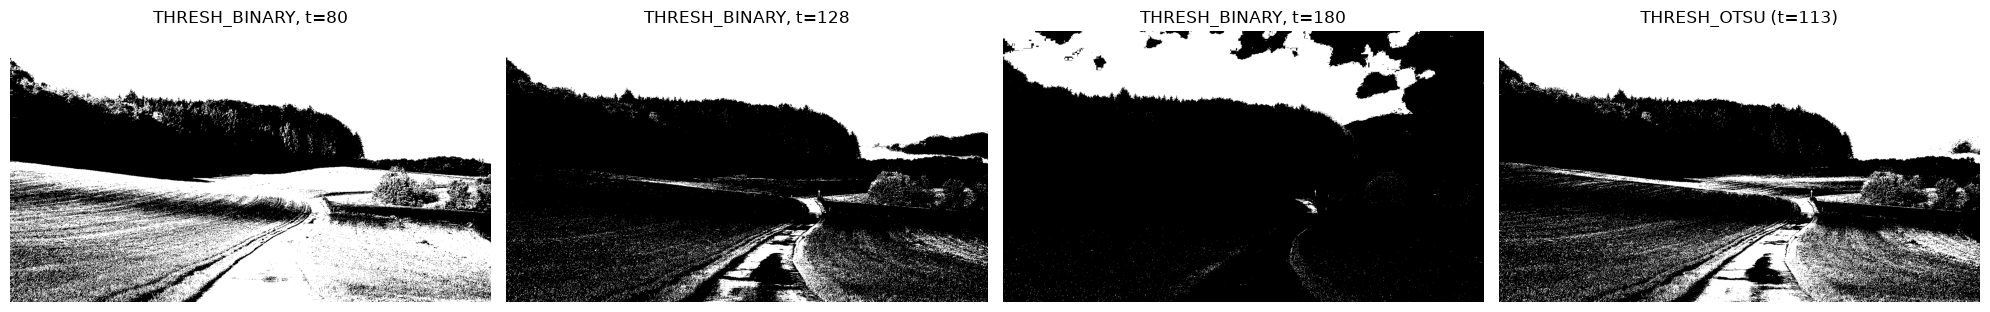

In [7]:
thresholds = [80, 128, 180]

fig, ax = plt.subplots(1, len(thresholds) + 1, figsize=(5 * (len(thresholds) + 1), 5))

# Обычная бинаризация с разными порогами
for i, t in enumerate(thresholds):
    _, th_bin = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    ax[i].imshow(th_bin, cmap='gray')
    ax[i].set_title(f'THRESH_BINARY, t={t}')
    ax[i].axis('off')
    print(f"[6] threshold={t}: белых пикселей = {np.count_nonzero(th_bin)} "
          f"({100.0 * np.count_nonzero(th_bin) / img.size:.2f}%)")

# Метод Оцу
otsu_thresh, otsu_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ax[-1].imshow(otsu_img, cmap='gray')
ax[-1].set_title(f'THRESH_OTSU (t={int(otsu_thresh)})')
ax[-1].axis('off')

print(f"[6] Otsu автоматически подобрал порог: {int(otsu_thresh)}")
print(f"[6] Otsu: белых пикселей = {np.count_nonzero(otsu_img)} "
      f"({100.0 * np.count_nonzero(otsu_img) / img.size:.2f}%)")

plt.tight_layout(); plt.show()

### Дополнительно: пороги в стиле TRUNC / TOZERO / TOZERO_INV

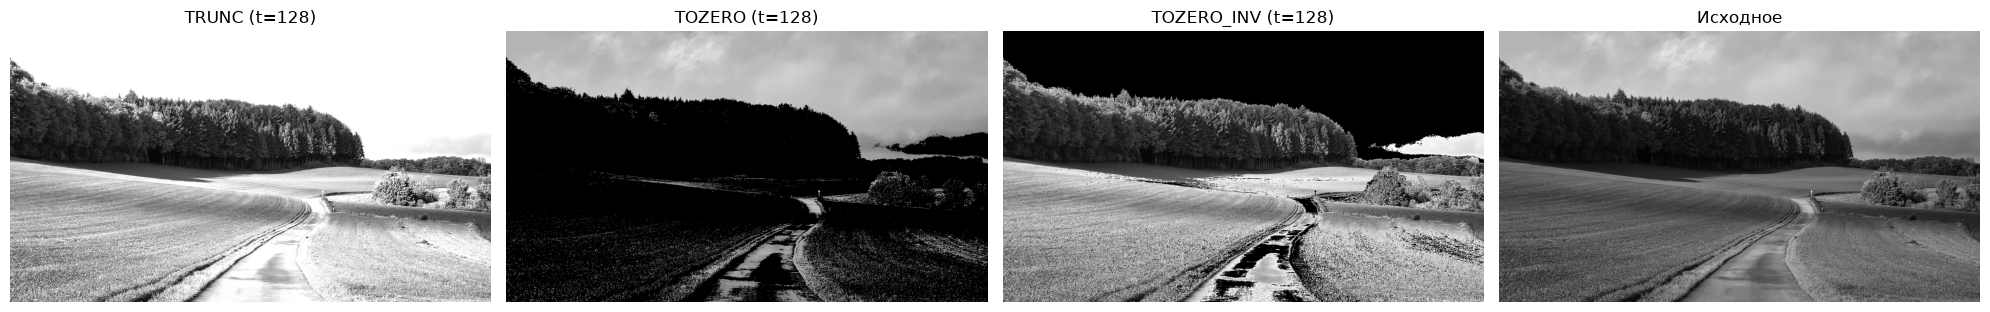

[6] TRUNC (t=128):      max=128, mean=90.33
[6] TOZERO (t=128):     max=255, mean=63.94
[6] TOZERO_INV (t=128): max=128, mean=43.79


In [8]:
t = 128

_, th_trunc   = cv2.threshold(img, t, 255, cv2.THRESH_TRUNC)
_, th_tozero  = cv2.threshold(img, t, 255, cv2.THRESH_TOZERO)
_, th_tozeroi = cv2.threshold(img, t, 255, cv2.THRESH_TOZERO_INV)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, im, title in zip(ax,
                        [th_trunc, th_tozero, th_tozeroi, img],
                        [f'TRUNC (t={t})', f'TOZERO (t={t})', f'TOZERO_INV (t={t})', 'Исходное']):
    a.imshow(im, cmap='gray'); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()

print(f"[6] TRUNC (t={t}):      max={th_trunc.max()}, mean={th_trunc.mean():.2f}")
print(f"[6] TOZERO (t={t}):     max={th_tozero.max()}, mean={th_tozero.mean():.2f}")
print(f"[6] TOZERO_INV (t={t}): max={th_tozeroi.max()}, mean={th_tozeroi.mean():.2f}")

## Итоговая визуализация всех этапов

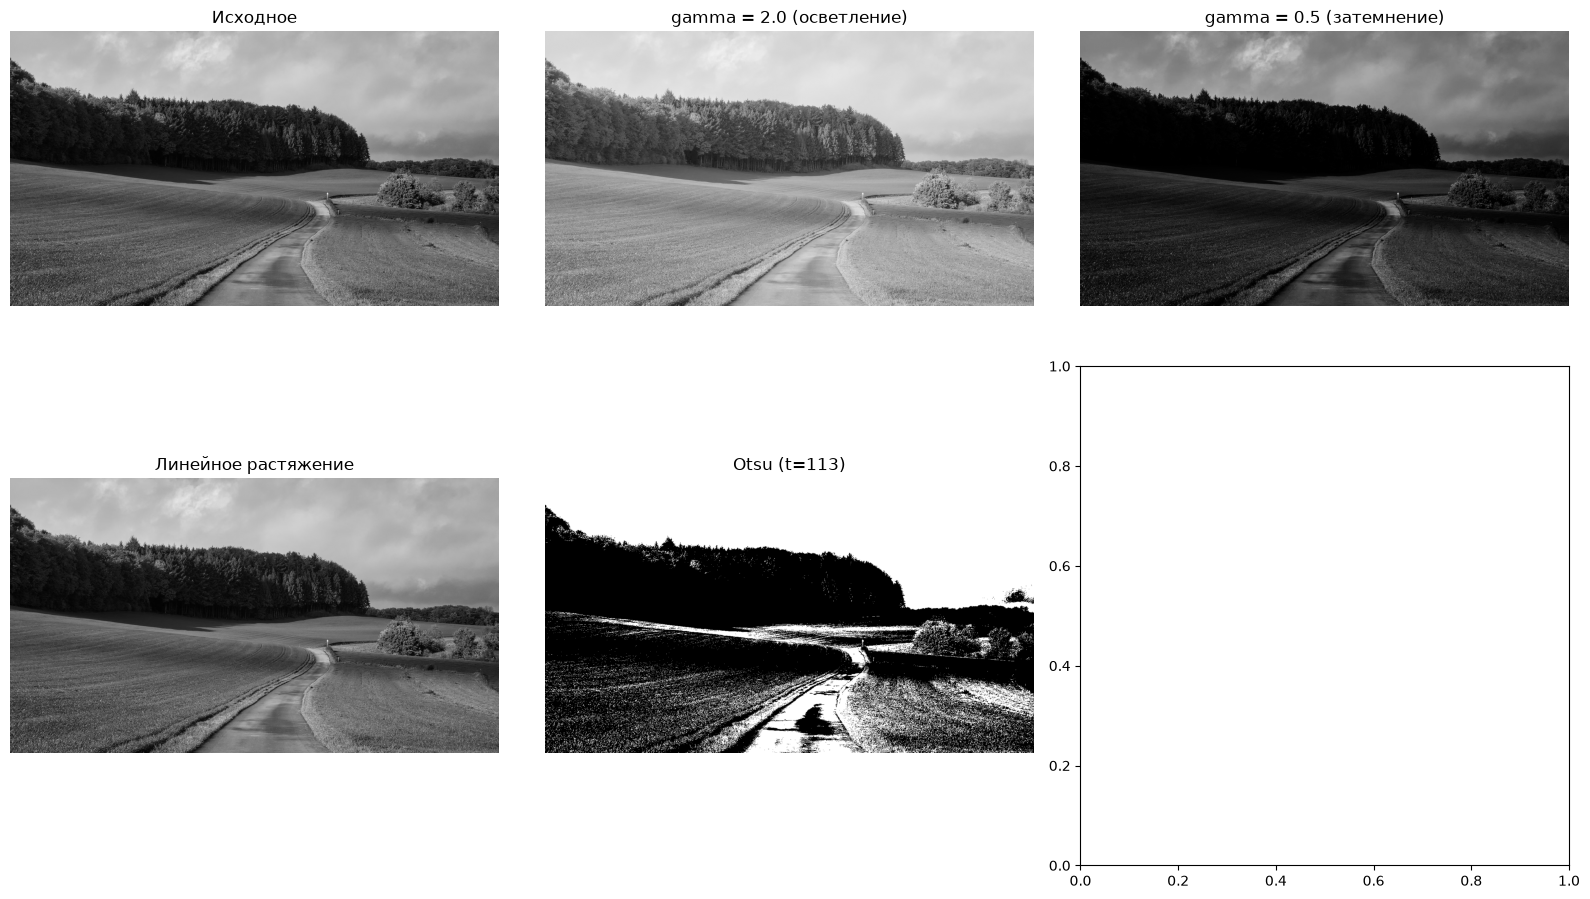

[OK] Все этапы выполнены.


In [9]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10))
items = [
    (img,         'Исходное'),
    (gamma_gt1,   'gamma = 2.0 (осветление)'),
    (gamma_lt1,   'gamma = 0.5 (затемнение)'),
    (lin_img,     'Линейное растяжение'),
    (otsu_img,    f'Otsu (t={int(otsu_thresh)})'),
]
for a, (im, title) in zip(ax.ravel(), items):
    a.imshow(im, cmap='gray'); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()

print("[OK] Все этапы выполнены.")